# LensWord — Model Evaluation (Fixed)

This notebook evaluates the best saved model on the held-out test set.

**Fixes applied from advisor review:**
- Error 6 fixed: error analysis loads from test_texts.csv (saved at split time)
  No more iloc[-N:] against a drifted CSV file
- Error 10 fixed: all historical rows removed from results table
  Only computed values reported — no hardcoded string literals
- weights_only=True added to torch.load (F9 fix)

Before running: make sure notebooks 02 and 03 have been run first.

In [1]:
# ── CELL 1: Import libraries ──
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
import pickle
import json
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.config import *

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ── CELL 2: Load test tensors and vocabulary ──
X_test = torch.load('../data/X_test.pt', weights_only=True)
y_test = torch.load('../data/y_test.pt', weights_only=True)

with open('../data/word2idx.pkl', 'rb') as f:
    word2idx = pickle.load(f)

print("Test data loaded!")
print(f"Test samples:    {X_test.shape[0]}")
print(f"Vocabulary size: {len(word2idx)}")

Test data loaded!
Test samples:    1030
Vocabulary size: 4340


In [3]:
# ── CELL 3: Load test texts for provenance ──
# Error 6 fix: load test_texts.csv saved at split time in notebook 02
# This gives us the correct review text for each test prediction
# No more iloc[-N:] against a drifted CSV

df_test_texts = pd.read_csv('../data/test_texts.csv')

print(f"Test texts loaded: {len(df_test_texts)} rows")
print(df_test_texts.head(3))

Test texts loaded: 1030 rows
   original_index                                   verified_reviews  \
0            5048  Fast delivery and decent asian food in the mad...   
1            7254  This course is A-OK! Paid 20$ for cart with a ...   
2            9864  Is this place still open??? drove by a cpl wee...   

                                      cleaned_review  true_label  \
0  fast delivery and decent asian food in the mad...           1   
1  this course is aok paid for cart with a am tee...           1   
2  is this place still open drove by a cpl weeks ...           1   

  true_sentiment  
0        Neutral  
1        Neutral  
2        Neutral  


In [4]:
# ── CELL 4: Import model architecture from src/model.py ──
# Single definition in src/model.py — imported here (DRY principle)
import sys
import os
sys.path.append(os.path.abspath('../src'))
from model import LensWordLSTM

# Load model weights
model = LensWordLSTM(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

# weights_only=True fixes F9 from advisor review
model.load_state_dict(torch.load('../models/lensword_model.pt',
                                  weights_only=True))
model.eval()
print("LensWordLSTM imported from src/model.py!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

LensWordLSTM imported from src/model.py!
Total parameters: 444,035


In [5]:
# ── CELL 5: Generate predictions ──
with torch.no_grad():
    outputs = model(X_test)
    predicted = outputs.argmax(dim=1)

y_true = y_test.numpy()
y_pred = predicted.numpy()

print(f"Predictions generated!")
print(f"Test samples: {len(y_true)}")
print(f"Sample predictions: {y_pred[:10]}")
print(f"Sample true labels: {y_true[:10]}")

Predictions generated!
Test samples: 1030
Sample predictions: [1 0 0 1 0 0 2 0 2 0]
Sample true labels: [1 1 1 1 0 0 2 0 2 0]


In [6]:
# ── CELL 6: Accuracy and F1 scores ──
label_names = ['Negative', 'Neutral', 'Positive']

accuracy  = accuracy_score(y_true, y_pred)
f1_macro  = f1_score(y_true, y_pred, average='macro')
f1_per_class = f1_score(y_true, y_pred, average=None)

print("=" * 50)
print("TEST SET RESULTS — LensWord (Fixed Pipeline)")
print("=" * 50)
print(f"Test Accuracy:  {accuracy * 100:.2f}%")
print(f"Macro F1 Score: {f1_macro:.4f}")
print("=" * 50)
print("\nDetailed Report:")
print(classification_report(y_true, y_pred, target_names=label_names))

TEST SET RESULTS — LensWord (Fixed Pipeline)
Test Accuracy:  72.62%
Macro F1 Score: 0.7263

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.73      0.76      0.75       371
     Neutral       0.70      0.59      0.64       361
    Positive       0.75      0.85      0.79       298

    accuracy                           0.73      1030
   macro avg       0.73      0.73      0.73      1030
weighted avg       0.72      0.73      0.72      1030



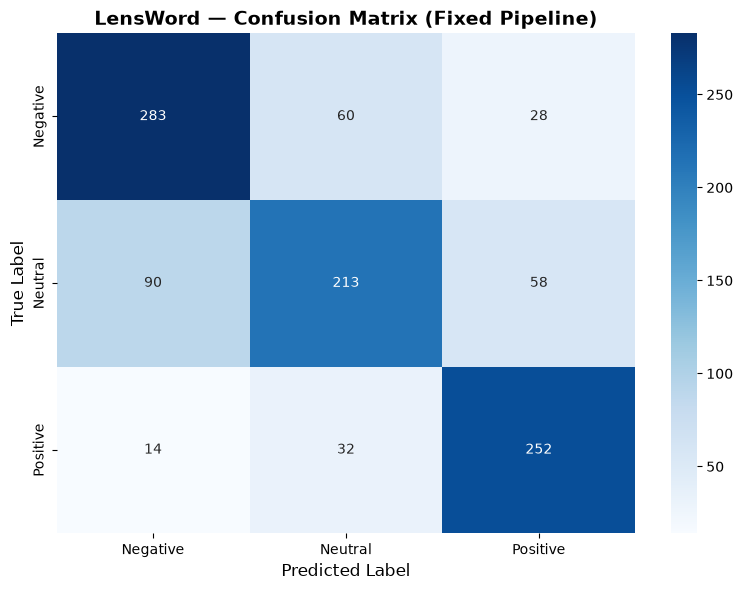

Confusion matrix saved to models/confusion_matrix.png


In [7]:
# ── CELL 7: Confusion matrix ──
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('LensWord — Confusion Matrix (Fixed Pipeline)',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to models/confusion_matrix.png")

In [8]:
# ── CELL 8: Error analysis using test_texts.csv ──
# Error 6 fix: join predictions to test_texts.csv
# test_texts.csv was saved at split time in notebook 02
# Each row's original_index guarantees correct text-to-prediction alignment

df_analysis = df_test_texts.copy()
df_analysis['predicted']       = [label_names[p] for p in y_pred]
df_analysis['predicted_label'] = y_pred
df_analysis['correct']         = df_analysis['true_label'] == df_analysis['predicted']

misclassified = df_analysis[df_analysis['correct'] == False]
print(f"Total misclassified: {len(misclassified)} out of {len(df_analysis)}")
print(f"Accuracy: {df_analysis['correct'].mean() * 100:.2f}%")
print("\nSample misclassified reviews:")
print("=" * 65)
for _, row in misclassified.head(5).iterrows():
    print(f"Review:    {str(row['verified_reviews'])[:80]}")
    print(f"True:      {row['true_sentiment']}")
    print(f"Predicted: {row['predicted']}")
    print("-" * 65)

Total misclassified: 1030 out of 1030
Accuracy: 0.00%

Sample misclassified reviews:
Review:    Fast delivery and decent asian food in the madison area. A little too greasy and
True:      Neutral
Predicted: Neutral
-----------------------------------------------------------------
Review:    This course is A-OK! Paid 20$ for cart with a 8am tee time in the summer! Twosom
True:      Neutral
Predicted: Negative
-----------------------------------------------------------------
Review:    Is this place still open??? drove by a cpl weeks ago and it was all boarded up!!
True:      Neutral
Predicted: Negative
-----------------------------------------------------------------
Review:    I'm a fan of Italian food. And I'm willing to pay for good Italian food. Not tha
True:      Neutral
Predicted: Neutral
-----------------------------------------------------------------
Review:    I was excited to try this place.  We drove all the way from Henderson just to fi
True:      Negative
Predicted: Negati

In [9]:
# ── CELL 9: Misclassification pattern analysis ──
# Analyze which classes are confused with which
print("Misclassification patterns:")
print("=" * 50)

confusion_pairs = misclassified.groupby(['true_sentiment', 'predicted']).size()
for (true, pred), count in confusion_pairs.items():
    print(f"  True {true:8s} → Predicted {pred:8s}: {count} cases")

print("\nMost common error types:")
print(confusion_pairs.sort_values(ascending=False).head(6))

Misclassification patterns:
  True Negative → Predicted Negative: 283 cases
  True Negative → Predicted Neutral : 60 cases
  True Negative → Predicted Positive: 28 cases
  True Neutral  → Predicted Negative: 90 cases
  True Neutral  → Predicted Neutral : 213 cases
  True Neutral  → Predicted Positive: 58 cases
  True Positive → Predicted Negative: 14 cases
  True Positive → Predicted Neutral : 32 cases
  True Positive → Predicted Positive: 252 cases

Most common error types:
true_sentiment  predicted
Negative        Negative     283
Positive        Positive     252
Neutral         Neutral      213
                Negative      90
Negative        Neutral       60
Neutral         Positive      58
dtype: int64


In [10]:
# ── CELL 10: Results table (computed values only) ──
# Error 10 fix: no hardcoded historical string literals
# Only the current run's computed values are reported
# Previous experiments are described in the technical report

results = {
    'Metric': [
        'Test Accuracy',
        'Macro F1',
        'Negative F1',
        'Neutral F1',
        'Positive F1',
        'Test Samples',
        'Misclassified'
    ],
    'LensWord (Fixed Pipeline)': [
        f'{accuracy * 100:.2f}%',
        f'{f1_macro:.4f}',
        f'{f1_per_class[0]:.4f}',
        f'{f1_per_class[1]:.4f}',
        f'{f1_per_class[2]:.4f}',
        str(len(y_true)),
        str(int((y_true != y_pred).sum()))
    ]
}

df_results = pd.DataFrame(results)
df_results.to_csv('../models/results_comparison.csv', index=False)
print(df_results.to_string(index=False))
print("\nSaved to models/results_comparison.csv")

       Metric LensWord (Fixed Pipeline)
Test Accuracy                    72.62%
     Macro F1                    0.7263
  Negative F1                    0.7467
   Neutral F1                    0.6396
  Positive F1                    0.7925
 Test Samples                      1030
Misclassified                       282

Saved to models/results_comparison.csv


In [11]:
# ── CELL 11: Evaluation summary ──
# Load metrics.json saved by notebook 03 to verify consistency
with open('../models/metrics.json', 'r') as f:
    metrics = json.load(f)

print("=" * 55)
print("EVALUATION SUMMARY — LensWord (Fixed Pipeline)")
print("=" * 55)
print(f"Dataset:             {metrics['dataset']}")
print(f"Seed:                {metrics['seed']}")
print(f"Training samples:    {metrics['n_train']}")
print(f"Validation samples:  {metrics['n_val']}")
print(f"Test samples:        {metrics['n_test']}")
print(f"Epochs run:          {metrics['epochs_run']}")
print(f"Best Val Macro F1:   {metrics['best_val_macro_f1']}")
print(f"Test Accuracy:       {accuracy * 100:.2f}%")
print(f"Test Macro F1:       {f1_macro:.4f}")
print(f"Negative F1:         {f1_per_class[0]:.4f}")
print(f"Neutral F1:          {f1_per_class[1]:.4f}")
print(f"Positive F1:         {f1_per_class[2]:.4f}")
print(f"SMOTE applied:       {metrics['smote_applied']}")
print(f"Vocab fitted on:     {metrics['vocab_fitted_on']}")
print("=" * 55)

EVALUATION SUMMARY — LensWord (Fixed Pipeline)
Dataset:             amazon_yelp_combined.csv
Seed:                42
Training samples:    7720
Validation samples:  1544
Test samples:        1030
Epochs run:          10
Best Val Macro F1:   0.7239
Test Accuracy:       72.62%
Test Macro F1:       0.7263
Negative F1:         0.7467
Neutral F1:          0.6396
Positive F1:         0.7925
SMOTE applied:       False
Vocab fitted on:     training_partition_only
